# PPO 训练监控清单
以下清单适用于 LLM RLHF/PPO 训练场景，重点监控策略稳定性、奖励信号质量、输出多样性和数值稳定性。
- <font color='red'>建议每 10~50 步打点记录一次，并在 WandB/TensorBoard 中设置阈值告警</font>

## 核心指标监控表

| 指标 | 正常范围 | 预警阈值 | 危险阈值 | 触发后的调参动作 |
|------|----------|----------|----------|-----------------|
| KL 散度（π_θ ‖ π_ref） | 0.01 ~ 0.1 | > 0.5 | > 5.0 | <font color='red'>增大 KL 惩罚系数 β（×1.5）；降低学习率；触发早停</font> |
| 策略熵 | 8 ~ 12 bits | 5 ~ 8 bits | < 5 bits（连续 10 步） | 增大 entropy_coef（×2）；检查是否奖励黑客 |
| Reward 均值 | 稳步上升 | 连续 5 步不涨 | 骤增后骤降 | <font color='red'>检查奖励模型是否有漏洞；做奖励归一化</font> |
| Reward 方差 | 适中 | 方差突然增大 3 倍 | 方差接近 0 | 裁剪极端奖励至 [-5, +5]；检查批次数据质量 |
| 梯度范数 | < 1.0 | > 5.0 | > 50.0 或 NaN | 降低学习率；启用梯度裁剪（max_norm=1.0） |
| Clip Fraction | 5% ~ 15% | > 20% | > 30% | 缩小 clip_range（如 0.2→0.1）；降低学习率 |
| Critic Explained Variance | > 0.8 | 0.5 ~ 0.8 | < 0.5 | 增大 Critic 学习率；增加 Critic 更新轮数 |
| Response Length | 与训练数据一致 | 突增/突降 50% | 固定为极短/极长 | 检查奖励模型是否偏好特定长度；加长度惩罚 |

## 分场景诊断与调参决策树
### 场景 A：KL 散度爆炸（策略偏离参考模型太远）

In [ ]:
KL > 5.0？
├── 是 → β 是否 < 0.01？
│       ├── 是 → 将 β 提升至 0.05~0.1
│       └── 否 → 学习率是否过大？
│               ├── 是 → 降低学习率至 1/5
│               └── 否 → 检查是否有极端奖励样本
│                       ├── 是 → 裁剪奖励 + 过滤异常 rollout
│                       └── 否 → 回滚到上一个稳定 checkpoint
└── 否 → 继续监控

#### 自适应 KL 控制伪代码：

In [ ]:
if kl_div > target_kl * 1.5:
    beta = beta * 1.5       # 增大惩罚
elif kl_div < target_kl / 1.5:
    beta = beta / 1.5       # 放松惩罚

### 场景 B：<font color='red'>熵坍塌（输出变成复读机）</font>

In [ ]:
策略熵连续 10 步 < 5 bits？
├── 是 → entropy_coef 是否为 0？
│       ├── 是 → 设置 entropy_coef = 0.01~0.1
│       └── 否 → 将 entropy_coef 翻倍
│               └── 是否仍无恢复？
│                       ├── 是 → 回滚 checkpoint + 降低学习率
│                       └── 否 → 继续训练
└── 否 → 正常

#### 熵（Entropy）衡量的是策略的随机性（探索能力）。
- 高熵 = 模型很迷茫，<font color='red'>什么都想试（探索强，利用弱）</font>。
  - 如果熵太高，模型学不到东西。
- 低熵 = 模型很自信，<font color='red'>只选它认为最好的那个（探索弱，利用强）</font>
  - 如果熵太低，模型会过早收敛到一个局部最优解（不再学习新东西）；

下面我结合你提供的表格内容，分三种场景举例解释这套逻辑是如何运作的：

#### 正常区间：8 ~ 12 bits

$H=log_2{1024}=10 bits$  （这 1024 个词概率都一样（都是 1/1024 ））
- 这就是最大熵，代表完全的随机和探索
- "正常区间 8~12 bits" 正中间。
- <font color='red'>如果熵只有 4 bits，相当于策略只像"从 16 个选项中做选择"那样随机</font>而实际有 1024 个选项——模型已经过度自信，陷入局部最优(有1024个选择，但是只从16个选项中选)。

**如果是 8 bits：**
**$2^8$=256**
  - 这意味着，虽然你有 1024 个选项，<font color='red'>但模型实际上只在前 256 个高频词里打转</font>，剩下的 768 个词它看都不看。

**如果是 5 bits（这是表格里的警戒线）：**
**$2^5$=32**
  - 这才是最可怕的！ 这意味着面对 1024 个可能的词，模型实际上只把概率分配给了区区 32 个词

In [1]:
from IPython.display import Image

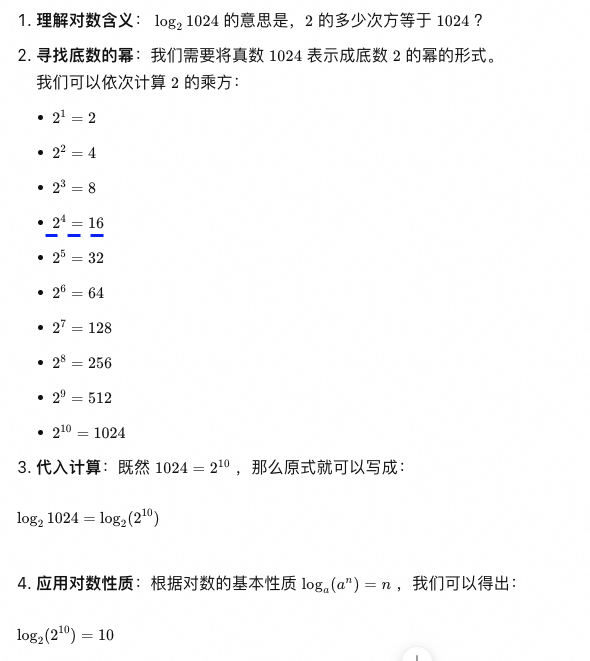

In [3]:
Image(filename='./Image/log.png')

- 含义： <font color='red'>这是最理想的状态。模型的探索和利用达到了平衡</font>
- 举例：
  - 假设你在训练一个写代码的 AI。此时它的熵是 10 bits。这意味着它在生成代码时，大部分时候能写出正确的语法（比如 def function():），但在变量命名或具体逻辑实现上，它会尝试几种不同的可能性。
  
- 系统行为：
  - 什么都不用做，保持当前的 entropy_coef（熵系数，用来控制熵在损失函数中权重的超参数）不变，让模型继续按这个节奏学习。
  
#### 轻微下降：5 ~ 8 bits
- 含义： <font color='red'>模型的随机性开始降低，它开始变得有点“固执”了</font>，可能正在快速收敛到某个特定的解法上。
- 举例：
  - AI 开始<font color='blue'>不管题目怎么变，都倾向于使用同一种解题模板</font>。<font color='green'>虽然目前准确率还在上升，但它已经不太愿意尝试新的思路了。</font>
  
- 系统行为：
  - <font color='red'>这是一个预警信号。虽然还没到危险区，但需要密切关注</font>。通常不需要剧烈操作，或者可以微调参数，观察它是否会继续下跌。
  
#### 严重过低：< 5 bits（连续 10 步）

这是表格中最关键的干预部分。
##### 现象描述
  - 数值低： <font color='red'>熵小于 5 bits，说明模型几乎变成了“确定性”的</font>。对于每一个输入，它几乎 100% 输出同一个 token。
  - <font color='red'>连续性： 这种状态持续了 10 个 step（步）。这排除了偶然的波动，确认模型陷入了模式崩塌。</font>
  
#### 举例场景
假设你在训练 AI 玩迷宫游戏。
  - 现状： AI 发现往右走一步能得 1 分，于是它不管迷宫长什么样，所有步骤都只输出“向右”。
  - 后果： 它的熵降到了 0.1 bits。<font color='red'>它不再探索左上角可能存在的出口</font>，因为它觉得“向右”最稳。这就是陷入了局部最优。
  
##### 干预手段 A：增大 entropy_coef (x2)
  - 原理： <font color='red'>entropy_coef 是加在损失函数里的“探索奖励”</font>
    - **增大它，等于告诉模型：“你别光顾着拿游戏的分数（Reward），你要多尝试不同的动作，尝试新动作我也给你加分！”**
  - 操作： 将系数乘以 2
  - 效果： <font color='red'>强迫模型把概率分布“抹平”一点</font>。
    - 原本它 99% 选“向右”，现在被迫变成 70% 选“向右”，30% 选“向左/向上/向下”。这就给了它重新发现正确路径的机会。


##### 干预手段 B：检查是否奖励黑客
  - 原理： 为什么模型会突然变得这么死板（熵骤降）？<font color='red'>通常是因为它找到了一个刷分的漏洞（Reward Hacking）</font>
  - 举例：
    - 游戏场景： <font color='red'>AI 发现只要原地转圈，就能通过某种 Bug 无限刷分</font>。于是它再也不去走迷宫了，就在那转圈。这时候它的策略非常单一（熵极低），但分数极高。
    - 对话场景： AI 发现只要回复“我不知道”或者重复一句话，就能避免犯错并获得安全奖励。
  - 操作： <font color='red'>此时单纯增大熵系数可能没用，因为刷分的诱惑太大了</font>。<font color='blue'>必须去检查 Reward Model（奖励模型）是不是给错了分，修补这个漏洞。</font>
  
#### 总结
这张图其实是一个自动化的“防呆”机制：
1. 熵太高或适中 -> 让它自己跑。
2. 熵变低了 -> 警告。
3. 熵太低且持续很久 -> 判定为“学傻了”或“卡住了”。
  - 药方1： 加大鼓励探索的力度（entropy_coef * 2）。
  - 药方2： 检查是不是因为发现了作弊码（Reward Hacking）导致的假象。  

### 场景 C：奖励骤增但质量下降（Reward Hacking）

In [ ]:
Reward 骤增 + KL 同步飙升？
├── 是 → 检查 top-k 高分样本的输出文本
│       ├── 发现固定句式/格式漏洞 → 修复奖励模型 + 裁剪奖励
│       └── 发现极长/极短输出 → 加入长度惩罚项
└── 否 → Reward 稳步上升？
        ├── 是 → 正常训练
        └── 否 → Reward 震荡剧烈 → 做批次内 Z-score 归一化

#### 核心场景：奖励飙升但质量下降
- 现象：
  - 训练过程中，你发现 Reward Model（奖励模型）给出的分数越来越高，甚至爆表。
- 矛盾点：
  - <font color='red'>虽然分数高了，但人类评估或者直观感觉模型的回答质量反而变差了</font>（比如变得啰嗦、重复、或者只会说套话）。
- 诊断目标：
  - <font color='red'>确认是否发生了 KL 散度失控</font>（模型偏离原始预训练模型太远），并找到对应的解决方案。
  
#### 决策树详解
##### 第一步：检查 KL 同步飙升？
- 含义：KL 散度衡量的是当前训练模型与初始参考模型之间的差异。
  - 是（KL 飙升）：
    - **说明模型为了拿高分，已经“面目全非”，彻底偏离了原本的语言能力，开始胡言乱语或过度拟合奖励模型的漏洞**。<font color='red'>这是典型的过拟合/崩溃前兆。</font>
  - 否（KL 正常）：
    - <font color='red'>说明模型还在可控范围内，可能只是奖励模型本身给分逻辑有问题</font>，或者是正常的波动。
  
##### 分支 A：如果是（KL 同步飙升）→ 检查 top-k 高分样本的输出文本
这时候必须看看到底模型输出了什么“作弊代码”。

1. <font color='red'>发现固定句式/格式漏洞</font>
  - 现象：**模型发现只要输出“根据我的分析...”或者某种特定的排版就能拿高分，于是它不管问题是什么，全都用这个格式回答**。这叫<font color='red'>“模式崩溃”</font>。
  - 对策：修复奖励模型 + 裁剪奖励。
    - 修复奖励模型：<font color='red'>把这种投机取巧的样本加入负反馈数据，重新训练奖励模型，让它学会识别这种作弊。</font>
    - 裁剪奖励：设置一个上限，比如单次回答最高只能得 5 分，防止模型靠一句话刷到 100 分。
    
2. <font color='red'>发现极长/极短输出</font>
  - 现象：模型发现写得越长，包含正确答案的概率越大（Verbose bias）；或者发现只回一个“好”字也能混过去。
  - 对策：加入长度惩罚项。在计算最终奖励时，减去一个与长度相关的系数。公式大概是：Final_Reward = Raw_Reward - β × Length。<font color='red'>强迫模型追求简洁有效</font>

##### 分支 B：如果否（KL 没有飙升，但 Reward 还是异常）
这说明模型还没“疯”，但是训练状态不对。
1. <font color='blue'>Reward 稳步上升？</font>
  - 判断：**这是最理想的状态。分数一点点涨，KL 也没乱飘。**
  - 对策：正常训练。不需要干预，继续保持。
  
2. Reward 震荡剧烈？
  - 现象：分数一会儿高一会儿低，像过山车一样，不稳定。
    - <font color='red'>这通常是因为不同 Batch 的数据难度差异太大，或者奖励模型的打分标准不一致（有的 Batch 普遍分高，有的普遍分低）。</font>
  - <font color='blue'>对策：做批次内 Z-score 归一化。</font>
  - 原理：不要直接用原始分数。在一个 Batch 内部，把分数转换成<font color='blue'>标准分（Z-score）</font>。
  - 公式: Advantage = $\frac{Reward - Mean(Batch)}{Std(Batch) + \epsilon}$
  - 作用：这就好比考试排名，不管卷子难易（Batch 差异），<font color='blue'>只看你在班里的相对排名。这样可以消除批次间的基准差异，让训练更稳定。</font>
  
#### 总结
这张图其实是一个RLHF 训练的“急救手册”：
- 怕模型学坏（KL 高）  →→  查输出，修补丁（惩罚长度、修补奖励模型漏洞）。
- 怕训练不稳（震荡）   →→  做归一化（Z-score）。
- 怕模型偷懒（刷分）   →→  限制奖励上限。

#### 核心功能
1. 自动检测：监控 KL 散度和 Reward 变化，判断是否进入“奖励劫持”状态。
2. 文本分析：自动计算生成文本的长度方差和重复率（检测固定句式）。
3. 动态干预：根据检测结果，自动应用长度惩罚或触发奖励裁剪。

##### 完整代码实现

In [ ]:
import torch
import numpy as np
from typing import List, Dict, Tuple, Optional

class RewardHackingGuard:
    """
    强化学习训练中的奖励劫持(Reward Hacking)防御卫士
    对应决策树逻辑：KL飙升检查 -> 文本模式分析 -> 动态惩罚/裁剪
    """

    def __init__(self, config: Dict):
        # 1. 阈值配置 (可根据实际训练情况调整)
        self.kl_threshold = config.get("kl_threshold", 0.5)      # KL 散度警戒线
        self.reward_spike_threshold = config.get("reward_spike_threshold", 2.0) # Reward 突增倍数
        
        # 2. 惩罚参数
        self.length_penalty_weight = config.get("length_penalty_weight", 0.01) # 长度惩罚系数 beta
        self.target_length = config.get("target_length", 200)    # 期望的目标 token 长度
        self.max_reward_clip = config.get("max_reward_clip", 10.0) # 奖励裁剪上限

    def check_and_fix(
        self, 
        rewards: torch.Tensor, 
        kl_divs: torch.Tensor, 
        generated_ids: List[List[int]], 
        tokenizer
    ) -> Tuple[torch.Tensor, Dict]:
        """
        主入口：在 PPO 更新前调用此函数
        
        Args:
            rewards: 原始奖励值 (Batch Size,)
            kl_divs: 当前步的 KL 散度 (Batch Size,)
            generated_ids: 模型生成的 token ids (List of Lists)
            tokenizer: 用于解码文本的 tokenizer
            
        Returns:
            adjusted_rewards: 修正后的奖励值
            logs: 调试日志字典
        """
        batch_size = len(rewards)
        adjusted_rewards = rewards.clone()
        logs = {"status": "normal"}

        # --- 步骤 1: 检查 KL 是否同步飙升 ---
        mean_kl = torch.mean(kl_divs).item()
        
        # 逻辑：如果平均 KL 超过阈值，或者 Reward 异常高，视为潜在风险
        is_kl_high = mean_kl > self.kl_threshold
        
        if is_kl_high:
            logs["status"] = "WARNING: High KL Detected"
            print(f"⚠️ 检测到 KL 散度过高 ({mean_kl:.4f})，启动文本深度分析...")
            
            # --- 步骤 2: 分析 Top-K 高分样本的文本特征 ---
            # 这里我们简化为分析当前 Batch 中的高分样本
            high_reward_mask = rewards > torch.mean(rewards) + torch.std(rewards)
            
            if torch.any(high_reward_mask):
                # 获取高分样本的文本
                suspicious_texts = [
                    tokenizer.decode(ids, skip_special_tokens=True) 
                    for ids, mask in zip(generated_ids, high_reward_mask) if mask
                ]
                
                # A. 检查极长/极短输出 (Length Hacking)
                lengths = [len(ids) for ids, mask in zip(generated_ids, high_reward_mask) if mask]
                avg_len = np.mean(lengths)
                
                # 如果平均长度严重偏离目标（比如超过目标长度的 2 倍或低于 0.5 倍）
                if avg_len > self.target_length * 1.5 or avg_len < self.target_length * 0.5:
                    print(f"   -> 发现长度异常 (Avg Len: {avg_len})，应用长度惩罚项")
                    logs["action"] = "apply_length_penalty"
                    
                    # 应用长度惩罚公式: R_new = R_old - beta * |len - target|
                    for i in range(batch_size):
                        current_len = len(generated_ids[i])
                        penalty = self.length_penalty_weight * abs(current_len - self.target_length)
                        adjusted_rewards[i] -= penalty
                        
                # B. 检查固定句式/重复 (Repetition Hacking)
                # 简单实现：计算 n-gram 重复率
                elif self._check_repetition(suspicious_texts):
                    print(f"   -> 发现高分样本存在高重复率/固定句式，建议修复 Reward Model")
                    logs["action"] = "suggest_rm_fix"
                    # 代码层面很难自动修复 RM，这里通常做法是降低这批数据的权重或直接裁剪奖励
                    adjusted_rewards[high_reward_mask] = 0.0 # 极端情况下直接归零作弊样本奖励
                    
            else:
                # KL 高但没有明显的高分样本，可能是整体漂移
                pass

        # --- 步骤 3: 全局安全网 - 奖励裁剪 (Reward Clipping) ---
        # 防止任何单点奖励过大导致梯度爆炸
        original_max = torch.max(rewards).item()
        adjusted_rewards = torch.clamp(adjusted_rewards, max=self.max_reward_clip)
        
        if original_max > self.max_reward_clip:
            logs["action"] = "reward_clipped"
            
        return adjusted_rewards, logs

    def _check_repetition(self, texts: List[str], threshold: float = 0.6) -> bool:
        """
        简单的重复率检测器
        如果文本中包含大量重复的短句或段落，返回 True
        """
        for text in texts:
            words = text.split()
            if len(words) < 10: continue
            
            # 检查 4-gram 重复 (连续4个词重复出现)
            n = 4
            ngrams = [tuple(words[i:i+n]) for i in range(len(words)-n)]
            if not ngrams: continue
            
            unique_ngrams = set(ngrams)
            repetition_rate = 1.0 - (len(unique_ngrams) / len(ngrams))
            
            if repetition_rate > threshold:
                return True
        return False

# ==========================================
# 模拟使用示例 (Mock Usage)
# ==========================================
if __name__ == "__main__":
    # 1. 初始化配置
    config = {
        "kl_threshold": 0.1,      # 设低一点方便演示触发
        "target_length": 50,      # 假设期望生成长度是 50 tokens
        "max_reward_clip": 5.0
    }
    
    guard = RewardHackingGuard(config)
    
    # 2. 模拟数据 (Batch Size = 3)
    # 样本 0: 正常
    # 样本 1: KL 极高且生成了超长废话 (模拟 Length Hacking)
    # 样本 2: KL 极高且生成了重复内容 (模拟 Repetition Hacking)
    
    mock_rewards = torch.tensor([1.0, 8.0, 6.0]) 
    mock_kls = torch.tensor([0.05, 0.8, 0.9]) 
    
    # 模拟 Token IDs (用数字代表 token)
    mock_generated_ids = [
        [101, 200, 300, 102],                                          # 短文本，正常
        [101] * 200 + [200] * 200,                                     # 超长文本 (400 tokens)
        [555, 666, 777] * 30                                           # 极度重复文本
    ]
    
    # 简单的 Mock Tokenizer
    class MockTokenizer:
        def decode(self, ids, **kwargs):
            return " ".join([str(i) for i in ids])
            
    tokenizer = MockTokenizer()
    
    # 3. 执行防御逻辑
    print("--- 开始防御检测 ---")
    new_rewards, log_info = guard.check_and_fix(mock_rewards, mock_kls, mock_generated_ids, tokenizer)
    
    print(f"原始奖励: {mock_rewards}")
    print(f"修正奖励: {new_rewards}")
    print(f"系统日志: {log_info}")

##### 代码逻辑解析
1. 输入参数设计
  - rewards & kl_divs：这是 PPO 算法中最核心的两个 Tensor。我们直接利用它们来判断“分数虚高”和“模型失控”。
  - generated_ids：这是模型的原始输出。为了检测“固定句式”或“长度作弊”，我们必须拿到具体的 Token 序列进行分析。
2. 决策树还原
  - 第一层判断 (is_kl_high)：
    - 对应图中的 KL 同步飙升?。
    - 只有当 KL 散度（模型偏离度）超过阈值时，才启动复杂的文本分析，避免浪费计算资源。
  - 第二层判断 (文本特征)：
    - 长度惩罚：代码中实现了 $R_new = R_{old} - β × |L - L_{target}$这能有效抑制模型通过输出几千字废话来骗取奖励的行为。
    - 重复率检测：使用 N-gram（这里是 4-gram）来检测文本是否由简单的片段循环组成。如果发现重复率过高，说明模型陷入了局部最优的“复读机”模式。

3.   - 安全兜底 (Clipping)
  - 无论前面的逻辑如何，最后一步 torch.clamp 是必须的。
  - 对应图中的 裁剪奖励。这能防止因为 Bug 或极端情况导致某个样本的 Reward 变成 1000+，从而毁掉整个模型的梯度更新。

##### 如何集成到你的训练中？
在你的 PPO 训练循环（Step 循环）中，找到计算完 rewards 但还没开始计算 advantages（优势函数）的地方，插入以下代码：

In [ ]:
# ... 在你的训练循环中 ...

# 1. 计算原始 Reward (来自 Reward Model)
rewards = reward_model(queries, responses)

# 2. 计算 KL (当前策略 vs 参考策略)
kl_divs = compute_kl(current_policy, ref_policy, queries)

# 3. 【插入点】调用防御卫士
adjusted_rewards, debug_logs = guard.check_and_fix(
    rewards=rewards,
    kl_divs=kl_divs,
    generated_ids=responses, # 注意传入生成的 token ids
    tokenizer=tokenizer
)

# 4. 使用修正后的 rewards 继续后续的 PPO 更新
advantages = compute_advantages(adjusted_rewards, values)
# ...

### 场景 D：梯度 NaN / Inf

In [ ]:
出现 NaN？
├── 是 → 检查 log_prob 是否下溢
│       ├── 是 → 在 log 空间求和，裁剪 log_prob 至 [-20, 0]
│       └── 否 → 检查奖励尺度
│               ├── 跨度过大 → 做 Z-score 归一化 + 裁剪至 [-5, +5]
│               └── 正常 → 检查是否 BF16 精度溢出
│                       ├── 是 → 奖励和价值函数改用 FP32 计算
│                       └── 否 → 降低学习率 + 回滚 checkpoint

#### 核心场景：NaN（Not a Number） 和 Inf（Infinity） 是训练崩溃的标志
一旦出现，模型参数就会变成乱码，训练必须立即停止并修复。这通常是因为计算过程中出现了“除以零”、“对负数取对数”或者“数字太大超出了计算机表示范围”的情况。

  - 现象：Loss 突然变成 nan，或者梯度（Gradients）变成 inf，导致训练中断。
  - 诊断目标：找到数值溢出的源头（是概率算崩了？奖励太大了？还是精度不够？）。
  
#### 决策树详解
##### 第一步：检查 log_prob 是否下溢？
含义：log_prob 是模型生成某个 token 的对数概率。概率 P 的范围是 (0,1] ，取对数后 log(P) 是负数。如果 P 极小（接近 0）， log(P) 就会趋向于负无穷（ −∞ ）。
  - 是（下溢）：说明模型生成了它认为“绝对不可能”的词，或者计算精度不够，导致概率变成了 0， log(0) 就是 −∞ ，进而导致后续计算全部崩溃。
  - 否（正常）：说明概率计算没问题，问题出在后面的奖励计算或参数更新上。
##### 分支 A：如果是（log_prob 下溢）→ 在 log 空间求和，裁剪 log_prob 至 [-20, 0]
这是针对概率计算的修复方案。
1. 在 log 空间求和
  - 原理：很多概率计算涉及连乘（ $P_1 × P_2 × …$ ）。多个小于 1 的数相乘会迅速趋近于 0，导致下溢。
  - 对策：利用数学性质 log(A×B)=logA+logB 。将“连乘”改为“对数相加”，可以极大地保持数值稳定性。
  
2. 裁剪 log_prob 至 [-20, 0]
  - 原理： $log(e^{−20})≈2×10^{−9}$，这已经是一个非常小的概率了。如果 log_prob < −20 ，说明模型在强行生成极不可能的词，这对训练没有正面意义，反而会带来巨大的梯度噪声。
  - 对策：强制将 log_prob 限制在 [−20,0] 之间。这相当于给概率设了一个“底线”，防止出现 −∞ 。
  
##### 分支 B：如果否（log_prob 正常）→ 检查奖励尺度
如果概率没问题，那通常是奖励值（Reward）太大，导致梯度更新步长过大，直接把参数“推飞”了。
1. 跨度是否过大？
  - 现象：不同样本的奖励差异巨大，比如有的得 0.1 分，有的得 1000 分。
  - 对策：做 Z-score 归一化 + 裁剪至 [-5, +5]。
    - Z-score： (x−μ)/σ 。把奖励拉回到均值为 0、方差为 1 的标准正态分布，消除量纲影响。
    - 硬裁剪：防止个别极端异常值（Outliers）破坏整体分布，强制限制在 [−5,5] 范围内。
    
##### 分支 C：如果奖励尺度正常 → 检查是否 BF16 精度溢出
1. 如果奖励也没问题，那很可能是硬件精度背锅。
是否是 BF16 精度溢出？
  - 背景：为了节省显存，现在训练大模型常用 BF16（Brain Floating Point 16）。虽然它比 FP16 范围大，但在处理极大或极小的梯度时，仍然可能溢出。
  - 对策：奖励和价值函数改用 FP32 计算。
    - 混合精度策略：模型前向传播可以用 BF16/FP16，但在计算 Loss、Reward 和 Value（价值网络输出）这些关键标量时，强制转回 FP32（32位浮点数）。FP32 的精度和范围远大于 BF16，能有效避免溢出。
    
##### 分支 D：如果以上都不是 → 降低学习率 + 回滚 checkpoint
这是最后的“救命稻草”。
  - 含义：如果数据、精度都没问题，那就是优化器步子迈太大了。
  - 对策：
    - 降低学习率：减小参数更新的幅度，让训练更平滑。
    - 回滚 checkpoint：因为已经出现 NaN 了，当前模型参数已经坏了（变成了 NaN），必须从上一个正常的保存点（Checkpoint）重新加载，然后以更小的学习率继续训练。
    
#### 总结
这张图的核心思想是“数值稳定性优先”。在 RLHF 训练中，为了防止模型练飞，我们通常需要：
1. 锁住概率（Log 空间计算 + 裁剪）。
2. 锁住奖励（归一化 + 裁剪）。
3. 锁住精度（关键计算用 FP32）。
4. 兜底机制（学习率衰减 + 存档回滚）。
这套流程是保证 PPO 算法不崩溃的标准工程实践。

#### 它完整复刻了图中的决策逻辑：先查概率下溢，再查奖励跨度，最后查精度溢出，并自动执行对应的修复操作。
核心功能
1. Log Prob 稳定性检查：检测是否出现 −∞ ，自动裁剪至 [-20, 0]。
2. 奖励归一化与裁剪：计算 Reward 的 Z-score，防止数值过大导致梯度爆炸。
3. 精度与回滚机制：监控 BF16 溢出，支持自动降级为 FP32 或触发训练回滚。

#### 完整代码实现

In [ ]:
import torch
import numpy as np
from typing import Dict, Optional, Tuple

class GradientStabilityGuard:
    """
    RLHF/PPO 训练稳定性卫士
    对应决策树逻辑：NaN/Inf 排查 -> LogProb裁剪 -> Reward归一化 -> 精度/回滚处理
    """

    def __init__(self, config: Dict):
        # 1. 阈值配置 (可根据实际模型调整)
        self.log_prob_min = config.get("log_prob_min", -20.0)   # log_prob 下限
        self.reward_clip_range = config.get("reward_clip_range", [-5.0, 5.0]) # Reward 裁剪范围
        self.z_score_norm = config.get("z_score_norm", True)   # 是否开启 Z-score 归一化

        # 2. 状态追踪
        self.should_rollback = False
        self.use_fp32_math = False  # 标记是否需要强制 FP32 计算

    def check_and_fix(self, log_probs: torch.Tensor, rewards: torch.Tensor, loss: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        主入口：在计算 Loss 前调用
        Args:
            log_probs: 模型生成的对数概率 (Batch, Seq_Len)
            rewards: 原始奖励分数 (Batch,)
            loss: 当前步的 Loss (用于检测 NaN)
        Returns:
            修复后的 log_probs 和 rewards
        """
        # --- 0. 全局 NaN/Inf 快速检查 ---
        if torch.isnan(loss) or torch.isinf(loss):
            print("⚠️ [CRITICAL] 检测到 Loss 为 NaN/Inf！启动紧急排查流程...")
            self._handle_nan_inf(log_probs, rewards)

        # --- 1. 修复 Log Prob 下溢 (对应图中第2-3行) ---
        fixed_log_probs = self._fix_log_prob_underflow(log_probs)

        # --- 2. 修复奖励跨度/溢出 (对应图中第4-6行) ---
        fixed_rewards = self._fix_reward_instability(rewards)

        return fixed_log_probs, fixed_rewards

    def _fix_log_prob_underflow(self, log_probs: torch.Tensor) -> torch.Tensor:
        """
        检查 log_prob 是否下溢 (-inf)，并裁剪至 [-20, 0]
        """
        has_underflow = torch.isinf(log_probs).any() or (log_probs < self.log_prob_min).any()

        if has_underflow:
            print(f"⚠️ [FIX] 检测到 log_prob 下溢/过小。执行裁剪至 [{self.log_prob_min}, 0]")
            # 核心操作：Clamp 裁剪
            return log_probs.clamp(min=self.log_prob_min, max=0.0)

        return log_probs

    def _fix_reward_instability(self, rewards: torch.Tensor) -> torch.Tensor:
        """
        检查奖励跨度，执行 Z-score 归一化 + 裁剪
        """
        # Z-score 归一化 (对应图中第5行)
        if self.z_score_norm and rewards.numel() > 1:
            mean = rewards.mean()
            std = rewards.std() + 1e-8  # 防止除以0
            rewards = (rewards - mean) / std

        # 裁剪至 [-5, 5] (对应图中第5行)
        min_r, max_r = self.reward_clip_range
        if (rewards < min_r).any() or (rewards > max_r).any():
            print(f"⚠️ [FIX] 检测到 Reward 跨度异常。执行 Z-score + 裁剪至 [{min_r}, {max_r}]")
            rewards = rewards.clamp(min=min_r, max=max_r)

        return rewards

    def _handle_nan_inf(self, log_probs: torch.Tensor, rewards: torch.Tensor):
        """
        当上述修复无效，Loss 依然 NaN 时的深度排查 (对应图中第7-8行)
        """
        # 检查是否是 BF16 精度溢出
        # 简单判断逻辑：如果输入包含 BF16 且出现了 Inf，大概率是精度不够
        if log_probs.dtype == torch.bfloat16 or rewards.dtype == torch.bfloat16:
            print("🛑 [ACTION] 怀疑 BF16 精度溢出。建议将 Value/Reward 计算切换至 FP32")
            self.use_fp32_math = True

        # 如果已经是 FP32 或者切换后依然报错，则判定为学习率过大
        else:
            print("🛑 [CRITICAL] 已使用高精度计算但仍 NaN。判定为梯度爆炸。")
            print("👉 [ACTION] 请立即降低学习率 (Learning Rate) 并回滚 Checkpoint！")
            self.should_rollback = True

# ==========================================
# 模拟集成示例 (伪代码)
# ==========================================
if __name__ == "__main__":
    # 配置参数
    config = {
        "log_prob_min": -20.0,
        "reward_clip_range": [-5.0, 5.0],
        "z_score_norm": True
    }

    guard = GradientStabilityGuard(config)

    # 模拟训练中的脏数据
    # 假设 log_prob 出现了 -inf，Reward 出现了 100.0 (异常大)
    dummy_log_probs = torch.tensor([[-0.1, -0.5, float('-inf')]], dtype=torch.float32)
    dummy_rewards = torch.tensor([100.0, 0.5, -0.2], dtype=torch.float32)
    dummy_loss = torch.tensor(float('nan')) # 模拟 Loss 爆炸

    print("--- 开始修复 ---")
    fixed_lp, fixed_rw = guard.check_and_fix(dummy_log_probs, dummy_rewards, dummy_loss)

    print(f"修复后 Log Probs: {fixed_lp}")
    print(f"修复后 Rewards: {fixed_rw}")
    if guard.should_rollback:
        print(">>> 触发回滚逻辑 <<<")

#### 代码逻辑详解
1. Log Prob 修复 (_fix_log_prob_underflow)
  - 问题：当模型生成某个 token 的概率极低时，log(prob) 会变成 -inf。在后续计算 Advantage 或 Loss 时，-inf * value 会导致整个梯度变成 NaN。
  - 解决：使用 .clamp(min=-20.0)。这意味着即使概率是 $  - 10^{−100}$  ，我们也只把它当作 e^{−20}来处理。这既保留了“这是一个低概率事件”的信号，又保证了数值是有限的。
  
2. 奖励双重保险 (_fix_reward_instability)
  - Z-score 归一化：(x - mean) / std。这一步非常关键，它把不同批次（Batch）的奖励拉回到同一个尺度（均值 0，方差 1）。防止某一批数据因为奖励模型打分普遍偏高，导致梯度过大。
  - 硬裁剪：clamp(-5, 5)。这是最后一道防线，确保没有任何单个样本的奖励能大到摧毁梯度。
3. 深度排查 (_handle_nan_inf)
  - BF16 vs FP32：BF16（Brain Floating Point）动态范围虽然比 FP16 大，但在计算指数（Exp）或对数（Log）时仍可能溢出。代码检测到 dtype 为 BF16 且出错时，会提示切换计算精度。
  - 回滚信号：如果精度没问题还是炸了，那通常是学习率太大导致参数更新步子迈大了。此时代码会设置 should_rollback = True，你在训练主循环中检测到这个标志，就可以加载上一个 Checkpoint 并减半学习率。

## 训练阶段差异化策略

| 阶段 | 学习率 | KL 系数 β | Clip ε | Entropy Coef | 重点监控 |
|------|--------|-----------|--------|-------------|---------|
| 早期（0~500 步） | 1e-7 ~ 1e-6 | 0.1 | 0.1 | 0.05 | KL 是否稳定、梯度是否 NaN |
| 中期（500~3000 步） | 3e-6 ~ 1e-5 | 0.02~0.05 | 0.2 | 0.01 | Reward 趋势、熵是否下降 |
| 后期（3000+ 步） | 衰减至 1e-7 | 自适应 | 0.1~0.2 | 0.01 | 是否过拟合、KL 是否反弹 |

## Checkpoint 管理策略
- 保存频率：每 50~100 步保存一次
- 评估机制：每次保存后在 held-out 验证集上评估
- 自动回滚条件：
  - 连续 3 个 checkpoint 验证性能下降 → 自动回滚到最佳 checkpoint
  - KL > 5.0 且持续 5 步 → 立即回滚
  - 策略熵 < 5 bits 持续 50 步 → 回滚并降低学习率 ×0.5
- 最佳 checkpoint 选择标准：验证集 reward 最高 且 KL < 1.0 且 熵 > 6 bits

## 推荐监控仪表盘配置
建议在 WandB/MLflow 中至少记录以下指标（每 10 步打点）：

In [ ]:
- train/kl_div          # KL 散度
- train/entropy         # 策略熵
- train/reward_mean     # 奖励均值
- train/reward_std      # 奖励标准差
- train/grad_norm       # 梯度范数
- train/clip_fraction   # Clip 比例
- train/approx_kl       # 近似 KL（新旧策略之间）
- train/value_loss      # Critic 损失
- train/explained_var   # Critic 解释方差
- train/lr              # 当前学习率
- generation/avg_length # 生成文本平均长度
- generation/sample     # 每 100 步记录一条生成样本（人工抽检）

### 关键原则：
- <font color='red'>监控不是为了"看热闹"，而是为了建立对训练过程的直觉。每次看到异常数字时，问自己："这个数字现在这样，合理吗？"</font>
   - 如果不合理，立即按决策树行动，不要等到训练彻底崩溃再补救。

# WandB 监控配置方案，
- 包含训练代码集成和仪表盘布局设计两部分，
- 可直接用于 LLM RLHF/PPO 训练场景。


## 训练代码集成（WandB 初始化 + 指标记录）

In [ ]:
import wandb
import torch

# ============ 1. 初始化 WandB ============
wandb.init(
    project="ppo-rlhf-training",
    name="exp-001-kl0.05-ent0.01",
    config={
        "learning_rate": 1e-6,
        "kl_coeff": 0.05,
        "entropy_coef": 0.01,
        "clip_range": 0.2,
        "batch_size": 128,
        "ppo_epochs": 4,
        "target_kl": 0.1,
    }
)

# ============ 2. 训练循环中记录指标 ============
for step in range(total_steps):
    # ... 你的 PPO 训练逻辑 ...

    # 每 10 步记录一次
    if step % 10 == 0:
        wandb.log({
            # --- 策略稳定性 ---
            "train/kl_div": kl_div,
            "train/approx_kl": approx_kl,
            "train/entropy": policy_entropy,
            "train/clip_fraction": clip_fraction,

            # --- 奖励信号 ---
            "train/reward_mean": reward_mean,
            "train/reward_std": reward_std,
            "train/reward_max": reward_max,
            "train/reward_min": reward_min,

            # --- Critic 质量 ---
            "train/value_loss": value_loss,
            "train/explained_var": explained_variance,

            # --- 优化器状态 ---
            "train/grad_norm": grad_norm,
            "train/lr": current_lr,
            "train/beta_kl": current_beta,

            # --- 生成质量 ---
            "generation/avg_length": avg_response_length,
            "generation/perplexity": perplexity,
        })

    # 每 100 步记录一条生成样本（人工抽检）
    if step % 100 == 0:
        sample_output = generate_sample(model, test_prompt)
        wandb.log({"generation/sample": wandb.Html(
            f"<pre>Prompt: {test_prompt}\n\nOutput: {sample_output}</pre>"
        )})

    # --- 阈值预警（触发时打 tag） ---
    if kl_div > 5.0:
        wandb.alert(title="🚨 KL 散度爆炸", text=f"KL={kl_div:.2f} at step {step}")
    if policy_entropy < 5.0:
        wandb.alert(title="⚠️ 策略熵过低", text=f"Entropy={policy_entropy:.2f} at step {step}")
    if torch.isnan(torch.tensor(grad_norm)):
        wandb.alert(title="💀 梯度 NaN", text=f"NaN detected at step {step}")

wandb.finish()

## WandB 仪表盘布局配置
在 WandB 项目页面点击 "Add panel" 或使用 "Create Report" 手动拖拽布局。推荐以下分区方案：
### 面板 1：策略稳定性（第一行，占满宽度）

| 面板名称 | 指标 | 图表类型 | 附加配置 |
|----------|------|----------|----------|
| KL 散度 | `train/kl_div` | Line | 添加 y=0.5 和 y=5.0 两条阈值线 |
| 近似 KL | `train/approx_kl` | Line | 与 KL 散度放同一图表，不同颜色 |
| 策略熵 | `train/entropy` | Line | 添加 y=5.0 和 y=8.0 两条阈值线 |
| Clip 比例 | `train/clip_fraction` | Line | 添加 y=0.2 和 y=0.3 阈值线 |

### 面板 2：奖励信号（第二行，左右分栏）
#### 左栏：

| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| Reward 均值 | `train/reward_mean` | Line（带滚动平均） |
| Reward 标准差 | `train/reward_std` | Line |

#### 右栏：
| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| Reward 分布 | `train/reward_max`, `train/reward_min` | Line（填充区域） |

### 面板 3：Critic 与优化器（第三行，左右分栏）
#### 左栏：

| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| Value Loss | `train/value_loss` | Line |
| Explained Variance | `train/explained_var` | Line（添加 y=0.5 阈值线） |

#### 右栏：
| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| 梯度范数 | `train/grad_norm` | Line（添加 y=5.0 和 y=50.0 阈值线） |
| 学习率 | `train/lr` | Line |
| KL 惩罚系数 β | `train/beta_kl` | Line |


### 面板 4：生成质量（第四行，左右分栏）
#### 左栏：

| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| 平均生成长度 | `generation/avg_length` | Line |
| Perplexity | `generation/perplexity` | Line |

#### 右栏：

| 面板名称 | 指标 | 图表类型 |
|----------|------|----------|
| 生成样本抽检 | `generation/sample` | HTML / Table |

## WandB Alert 规则配置
在 WandB 项目设置中配置以下自动告警（Settings → Alerts）：

In [ ]:
alerts:
  - name: "KL 散度爆炸"
    metric: "train/kl_div"
    condition: ">"
    threshold: 5.0
    wait_minutes: 5
    notification: ["slack", "email"]

  - name: "策略熵过低"
    metric: "train/entropy"
    condition: "<"
    threshold: 5.0
    wait_minutes: 10
    notification: ["slack"]

  - name: "梯度 NaN"
    metric: "train/grad_norm"
    condition: "is_nan"
    threshold: null
    wait_minutes: 0
    notification: ["slack", "email"]

  - name: "Reward 骤降"
    metric: "train/reward_mean"
    condition: "decrease_by"
    threshold: 50%  # 相对前 10 步均值下降 50%
    wait_minutes: 5
    notification: ["slack"]

## 多实验对比视图
当运行多个实验时，建议在 WandB 的 "Run Comparison" 页面添加以下对比面板：

In [ ]:
# 对比维度
- X 轴: train/kl_div
- Y 轴: train/reward_mean
- 颜色: config.entropy_coef
- 大小: config.learning_rate

这样可以直观看到：在相同 KL 约束下，不同超参数组合的 reward 表现差异，快速定位最优配置。

## 快速启动命令
如果你使用 TRL 库进行 PPO 训练，可以直接在配置中启用 WandB：

In [ ]:
from trl import PPOConfig

ppo_config = PPOConfig(
    report_to="wandb",          # 启用 WandB 日志
    run_name="exp-001",
    logging_first_step=True,    # 记录第一步数据
)

使用 TRL 时，上述大部分指标（KL、entropy、reward、value_loss、clip_fraction 等）会被自动记录，无需手动 wandb.log，只需在 WandB 上按上述布局配置仪表盘即可。

# 通过 WandB Python SDK 自动创建 Alert 规则的完整代码
- 可直接集成到你的训练脚本中，无需手动在网页上配置。

## 通过 SDK 创建 Alert 规则

In [ ]:
import wandb

# ============ 初始化 API 客户端 ============
api = wandb.Api()

# 替换为你的 entity（用户名或团队名）和项目名
ENTITY = "your-entity"
PROJECT = "ppo-rlhf-training"

# ============ 定义 Alert 规则 ============
alerts = [
    {
        "name": "🚨 KL 散度爆炸",
        "query": f"""
        SELECT run.id, run.name, latest(run.history["train/kl_div"]) as kl
        FROM {ENTITY}/{PROJECT}
        WHERE kl > 5.0
        """,
        "severity": "critical",
        "wait_minutes": 5,
        "message": "KL 散度超过 5.0，当前值: {{kl:.2f}}，建议立即增大 β 或回滚 checkpoint",
    },
    {
        "name": "⚠️ 策略熵过低",
        "query": f"""
        SELECT run.id, run.name, latest(run.history["train/entropy"]) as entropy
        FROM {ENTITY}/{PROJECT}
        WHERE entropy < 5.0
        """,
        "severity": "high",
        "wait_minutes": 10,
        "message": "策略熵低于 5.0 bits，当前值: {{entropy:.2f}}，建议增大 entropy_coef",
    },
    {
        "name": "💀 梯度 NaN 检测",
        "query": f"""
        SELECT run.id, run.name, latest(run.history["train/grad_norm"]) as grad
        FROM {ENTITY}/{PROJECT}
        WHERE grad IS NULL OR grad > 50.0
        """,
        "severity": "critical",
        "wait_minutes": 0,
        "message": "梯度异常（NaN 或范数 > 50），建议立即降低学习率并回滚",
    },
    {
        "name": "📉 Reward 骤降",
        "query": f"""
        SELECT run.id, run.name,
               latest(run.history["train/reward_mean"]) as reward_now,
               avg(run.history["train/reward_mean"], window=10) as reward_avg
        FROM {ENTITY}/{PROJECT}
        WHERE reward_now < reward_avg * 0.5
        """,
        "severity": "high",
        "wait_minutes": 5,
        "message": "Reward 相对近 10 步均值下降超过 50%，可能存在奖励黑客或数据异常",
    },
    {
        "name": "📈 Reward 虚高 + KL 爆炸（Reward Hacking）",
        "query": f"""
        SELECT run.id, run.name,
               latest(run.history["train/reward_mean"]) as reward,
               latest(run.history["train/kl_div"]) as kl
        FROM {ENTITY}/{PROJECT}
        WHERE reward > 3.0 AND kl > 2.0
        """,
        "severity": "high",
        "wait_minutes": 5,
        "message": "Reward 虚高且 KL 同步飙升，疑似 Reward Hacking，建议检查高分样本输出",
    },
]

# ============ 创建 Alert ============
for alert_config in alerts:
    try:
        api.create_alert(
            project=f"{ENTITY}/{PROJECT}",
            name=alert_config["name"],
            query=alert_config["query"],
            severity=alert_config["severity"],
            wait_minutes=alert_config["wait_minutes"],
            message=alert_config["message"],
        )
        print(f"✅ Alert 创建成功: {alert_config['name']}")
    except Exception as e:
        print(f"❌ Alert 创建失败: {alert_config['name']} - {e}")

## 通知渠道配置（Slack / Email）
Alert 创建后，还需要配置通知渠道。可以通过 SDK 完成：

In [ ]:
# ============ 配置通知渠道 ============
# 方式 1：通过 WandB 设置页面配置（推荐）
# 访问 https://wandb.ai/settings -> Notifications
# 绑定 Slack Webhook 或 Email

# 方式 2：通过 SDK 配置（需要 admin 权限）
api.update_project(
    entity=ENTITY,
    name=PROJECT,
    settings={
        "alerts": {
            "slack_webhook_url": "https://hooks.slack.com/services/YOUR/WEBHOOK/URL",
            "email_recipients": ["your-email@example.com"],
            "notify_on": ["critical", "high"],  # 只通知严重和高危级别
        }
    }
)

## 集成到训练脚本的完整示例

In [ ]:
import wandb
import torch

# ============ 1. 初始化 ============
wandb.init(
    project="ppo-rlhf-training",
    name="exp-001",
    config={
        "learning_rate": 1e-6,
        "kl_coeff": 0.05,
        "entropy_coef": 0.01,
    }
)

# ============ 2. 自动创建 Alert 规则 ============
setup_alerts(entity="your-entity", project="ppo-rlhf-training")

# ============ 3. 训练循环 ============
for step in range(total_steps):
    # ... PPO 训练逻辑 ...

    # 记录指标
    if step % 10 == 0:
        wandb.log({
            "train/kl_div": kl_div,
            "train/entropy": policy_entropy,
            "train/reward_mean": reward_mean,
            "train/grad_norm": grad_norm,
            # ... 其他指标 ...
        })

    # ============ 4. 训练内即时预警（不依赖 WandB Alert） ============
    # 这种方式更实时，适合需要在代码中立即执行动作的场景
    if kl_div > 5.0:
        print(f"🚨 [Step {step}] KL 散度爆炸: {kl_div:.2f}")
        wandb.alert(
            title="🚨 KL 散度爆炸",
            text=f"KL={kl_div:.2f} at step {step}",
            level=wandb.AlertLevel.CRITICAL
        )
        # 可选：自动执行修复动作
        # current_beta *= 1.5
        # rollback_checkpoint()

    if policy_entropy < 5.0:
        print(f"⚠️ [Step {step}] 策略熵过低: {policy_entropy:.2f}")
        wandb.alert(
            title="⚠️ 策略熵过低",
            text=f"Entropy={policy_entropy:.2f} at step {step}",
            level=wandb.AlertLevel.HIGH
        )

    if torch.isnan(torch.tensor(grad_norm)):
        print(f"💀 [Step {step}] 梯度 NaN!")
        wandb.alert(
            title="💀 梯度 NaN",
            text=f"NaN detected at step {step}",
            level=wandb.AlertLevel.CRITICAL
        )
        break  # 立即终止训练

wandb.finish()

## 两种预警方式对比

| 维度 | WandB Alert（服务端） | 训练内 `wandb.alert()`（客户端） |
|------|----------------------|-------------------------------|
| 实时性 | 有延迟（5~10 分钟轮询） | 即时（每步检查） |
| 执行环境 | 服务端独立运行，训练挂了也能报警 | 依赖训练进程存活 |
| 可执行动作 | 仅通知，不能自动调参 | 可在代码中立即执行修复动作 |
| 适用场景 | 长时间训练、无人值守 | 需要自动回滚/调参的场景 |

### 推荐组合使用：
- 训练内 wandb.alert() 负责即时检测和自动修复，WandB Alert（服务端）作为兜底，防止训练进程崩溃后无人知晓。


## 快速验证 Alert 是否生效

In [ ]:
# 发送一条测试 Alert
wandb.alert(
    title="🧪 测试告警",
    text="这是一条测试消息，如果你收到了说明 Alert 配置正确",
    level=wandb.AlertLevel.INFO
)

运行后检查你的 Slack/Email 是否收到通知，确认通知链路畅通后即可开始正式训练。